In [1]:
# Cell 1: 安装依赖
import os
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
import operator

load_dotenv(override=True)

# 关闭 LangSmith（本地调试）
os.environ["LANGCHAIN_TRACING_V2"] = "false"

print("✅ Day 6 环境准备完成")

✅ Day 6 环境准备完成


In [2]:
# Cell 2: State + LLM
class AgentState(TypedDict):
    messages: Annotated[list, operator.add]
    next: str
    reflections: Annotated[list, operator.add]   # 反思记录

from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage

llm = ChatOllama(
    model="qwen2.5:14b",
    temperature=0.7,
    num_ctx=8192,
    num_gpu=999,
    base_url="http://host.docker.internal:11434"
)

# Cell 0: Groq 配置（最快远程 LLM）
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

# llm = ChatGroq(
#     model="llama-3.3-70b-versatile",   # 目前最推荐（速度 + 智能平衡好）
#     temperature=0.7,
#     max_tokens=2048,
#     streaming=True,                    # 支持流式输出（推荐）
# )


print("✅ LLM 初始化完成")

✅ LLM 初始化完成


In [3]:
# Cell 3: 工具
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

tavily_tool = TavilySearch(max_results=5, search_depth="advanced", include_answer=True)

@tool
def analyze_code(code: str) -> str:
    """分析代码质量、 bug 和改进建议"""
    prompt = f"请分析以下代码的质量、潜在问题和改进建议：\n\n{code}"
    return llm.invoke(prompt).content

tools = [tavily_tool, analyze_code]
print("✅ 工具加载完成")

✅ 工具加载完成


In [4]:
# Cell 4: Supervisor（关键修复）
supervisor_prompt = SystemMessage(content="""你是一个严格且高效的 Supervisor。

可用节点：
- Researcher：需要搜索信息或最新最佳实践时使用
- Coder：需要编写代码时使用
- Reviewer：需要审查代码时使用
- Final_Answer：当任务已经完成（代码已编写并审查通过）时使用

当前状态判断规则：
- 如果刚刚完成 Coding → 应该去 Reviewer
- 如果刚刚完成 Review → 应该去 Final_Answer
- 不要在 Reviewer 和 Reflection 之间反复循环

只返回上面4个节点(Researcher,Coder, Reviewer,Final_Answer)中的一个节点名称，不要解释。

当前对话历史：{messages}""")
MAX_STEPS = 30
def supervisor_node(state: AgentState):
    last_msg = state["messages"][-1].content
    prompt = supervisor_prompt.content.format(messages=state["messages"][-8:])  # 取最近历史
    # if len(state["messages"]) > MAX_STEPS * 2:
    #     print("⚠️ 达到最大步数，强制结束")
    #     return {"next": "Final_Answer"}
    response = llm.invoke([SystemMessage(content=prompt)])
    decision = response.content.strip().split("\n")[0].strip()
    if len(state["messages"]) > MAX_STEPS:
        return {"next": "Final_Answer"}
    node_map = {
        "final_answer": "Final_Answer",
        "final": "Final_Answer",
        "结束": "Final_Answer",
        "完成": "Final_Answer"
    }
    
    next_node = node_map.get(decision.lower(), decision)
    print(f"🔀 Supervisor 决定 → {next_node}")
    return {"next": next_node}

In [8]:
# Cell 5: 专业 Agent
from langchain.agents import create_agent

researcher = create_agent(
    model=llm,
    tools=tools,
    system_prompt=SystemMessage(content="你是技术研究员，擅长查找最新最佳实践和技术方案。")
)

coder = create_agent(
    model=llm,
    tools=tools,
    system_prompt=SystemMessage(content="你是资深 Python/C# 开发者，擅长编写高质量、可维护的代码。")
)

reviewer = create_agent(
    model=llm,
    tools=tools,
    system_prompt=SystemMessage(content="你是严格的代码审查专家，专注于代码质量、安全性和可维护性。")
)

print("✅ 三个专业 Agent 创建完成")

✅ 三个专业 Agent 创建完成


In [9]:
# Cell 6: Reflection（改进版）
reflection_prompt = SystemMessage(content="""你是一个专业的反思节点。

请对当前工作进行总结，并明确判断下一步应该怎么做。

当前历史：{messages}

请按以下格式输出：
总结：...
问题：...
下一步建议：（明确写出应该去哪个节点：Reviewer / Coder / Final_Answer）""")

def reflection_node(state: AgentState):
    messages = state["messages"][-10:]   # 取更多历史
    prompt = reflection_prompt.content.format(messages=messages)
    
    response = llm.invoke([SystemMessage(content=prompt)])
    reflection_text = response.content
    
    print("🤔 Reflection:", reflection_text[:200] + "..." if len(reflection_text) > 200 else reflection_text)
    
    return {
        "reflections": [reflection_text],
        "messages": [HumanMessage(content=f"[Reflection] {reflection_text}")]
    }

def researcher_node(state: AgentState):
    # print(f"researcher_node state {state["messages"]}")
    result = researcher.invoke(state)
    # print(f"researcher_node result {result["messages"][-1]}")
    return {"messages": result["messages"]}

def coder_node(state: AgentState):
    # print(f"coder_node state {state["messages"][-1]}")
    result = coder.invoke(state)
    # print(f"coder_node result {result["messages"][-1]}")
    return {"messages": result["messages"]}

def reviewer_node(state: AgentState):
    # print(f"reviewer_node state {state["messages"][-1]}")
    result = reviewer.invoke(state)
    # print(f"reviewer_node result {result["messages"][-1]}")
    return {"messages": result["messages"]}

In [10]:
# Cell 7: 构建 Graph
from langgraph.graph import END, StateGraph,START


workflow = StateGraph(AgentState)

workflow.add_node("Supervisor", supervisor_node)
workflow.add_node("Researcher", researcher_node)
workflow.add_node("Coder", coder_node)
workflow.add_node("Reviewer", reviewer_node)
workflow.add_node("Reflection", reflection_node)
workflow.add_node("Final_Answer", lambda state: state)

workflow.add_edge(START, "Supervisor")

workflow.add_conditional_edges(
    "Supervisor",
    lambda state: state["next"],
    {
        "Researcher": "Researcher",
        "Coder": "Coder",
        "Reviewer": "Reviewer",
        "Final_Answer": END,
    }
)

# 各 Agent 执行完后进入 Reflection
for node in ["Researcher", "Coder", "Reviewer"]:
    workflow.add_edge(node, "Reflection")

# Reflection 完成后回到 Supervisor 继续决策
workflow.add_edge("Reflection", "Supervisor")

multi_agent = workflow.compile()

print("✅ Day 6 多代理反思系统构建完成！")

✅ Day 6 多代理反思系统构建完成！


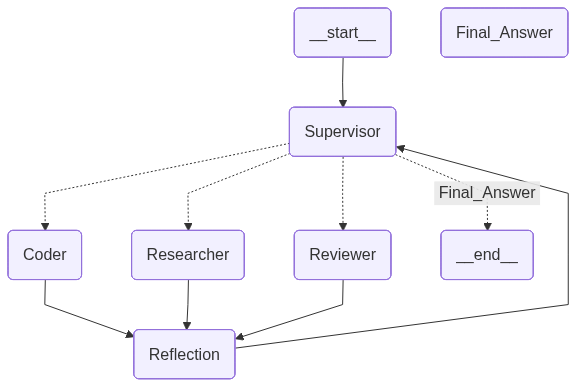

In [11]:
# ==================== 8. 可视化 ====================
from IPython.display import Image, display
display(Image(multi_agent.get_graph().draw_mermaid_png()))

In [12]:
# Cell 8: 测试
def run_task(query: str):
    print(f"\n🚀 开始任务: {query}\n")
    
    result = multi_agent.invoke({
        "messages": [HumanMessage(content=query)]
    })
    
    print("\n" + "="*80)
    print("✅ 最终回答：")
    print(result["messages"][-1].content)
    print("="*80)
    
    return result

# 测试
run_task("帮我实现一个 FastAPI 的用户注册接口，要求包含密码加密、邮箱验证逻辑，并进行代码审查")


🚀 开始任务: 帮我实现一个 FastAPI 的用户注册接口，要求包含密码加密、邮箱验证逻辑，并进行代码审查

🔀 Supervisor 决定 → Coder
🤔 Reflection: 总结：我们已经为 FastAPI 用户注册接口创建了一个基本的实现，包括密码加密和邮箱验证功能。代码使用了 bcrypt 进行密码哈希，并通过生成唯一 token 发送邮件进行邮箱验证。接下来需要进一步完善 email 验证部分的具体实现以及调用外部工具对代码进行审查。

问题：email 验证逻辑中没有具体描述如何处理用户点击验证链接后的操作，且尚未完成外部代码审查以确保质量和安全性。

下一步...
🔀 Supervisor 决定 → Reviewer
🤔 Reflection: 总结：我们已经为 FastAPI 用户注册接口创建了一个基本的实现，包括密码加密和邮箱验证功能。代码使用了 bcrypt 进行密码哈希，并通过生成唯一 token 发送邮件进行邮箱验证。此外，已经完成了初步的质量审查并提出了一系列改进措施。

问题：
1. 代码中直接使用字典存储用户信息，在实际应用中需要迁移到数据库。
2. 用户注册流程中缺少对用户名唯一性的检查和详细的错误处理机制。
3. 邮件...
🔀 Supervisor 决定 → Reviewer
🤔 Reflection: ### 总结
我们已经完成了 FastAPI 用户注册接口的基本实现，包括密码加密和邮箱验证功能。通过质量审查后，提出了多项改进措施，并实现了以下几点：

1. 将用户信息迁移到持久化数据库中。
2. 完善了用户名唯一性和详细的错误处理机制。
3. 在邮件发送逻辑中增加了异常捕获以确保服务稳定性。
4. 使用环境变量存储敏感配置。

### 问题
尽管我们已经完成了上述改进，但仍然存在一些需要进一...
🔀 Supervisor 决定 → Reviewer
🤔 Reflection: ### 总结

通过之前的审查和反馈，我们已经完善了用户注册接口的实现。具体改进包括：

1. **导入不完整**：确保所有必需的库和类都被正确导入。
2. **缺少数据库模型定义**：提供了完整的数据库模型定义。
3. **安全性问题**：使用更安全的机制来创建和验证认证令牌，例如JSON Web Tokens (JWT)。
4. **

{'messages': [HumanMessage(content='帮我实现一个 FastAPI 的用户注册接口，要求包含密码加密、邮箱验证逻辑，并进行代码审查', additional_kwargs={}, response_metadata={}, id='d604cd1f-0c27-4a26-b066-6005e2606d3d'),
  HumanMessage(content='帮我实现一个 FastAPI 的用户注册接口，要求包含密码加密、邮箱验证逻辑，并进行代码审查', additional_kwargs={}, response_metadata={}, id='d604cd1f-0c27-4a26-b066-6005e2606d3d'),
  AIMessage(content='为了帮助您创建一个符合需求的FastAPI用户注册接口，我们将分步骤来完成这个任务。首先我会提供一段基础的示例代码，然后我们将添加密码加密和邮箱验证功能。\n\n### 步骤 1: 基础 FastAPI 用户注册 API\n\n```python\nfrom fastapi import FastAPI, HTTPException, Depends\nfrom pydantic import BaseModel\nimport hashlib\nfrom email_validator import validate_email, EmailNotValidError\nfrom typing import Optional\nimport secrets\n\napp = FastAPI()\n\nclass User(BaseModel):\n    username: str\n    password: str\n    email: str\n\n@app.post("/register/")\nasync def register(user: User):\n    # 假设这里有一个数据库连接，用于存储用户信息。暂时使用字典模拟。\n    users_db = {}\n    \n    if user.email in users_db:\n        raise HTTPException(status_code=400, detail="Em